In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torchdyn.core import NeuralODE

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

print("device:", device)

device: cuda


# 1. Toy Distribution

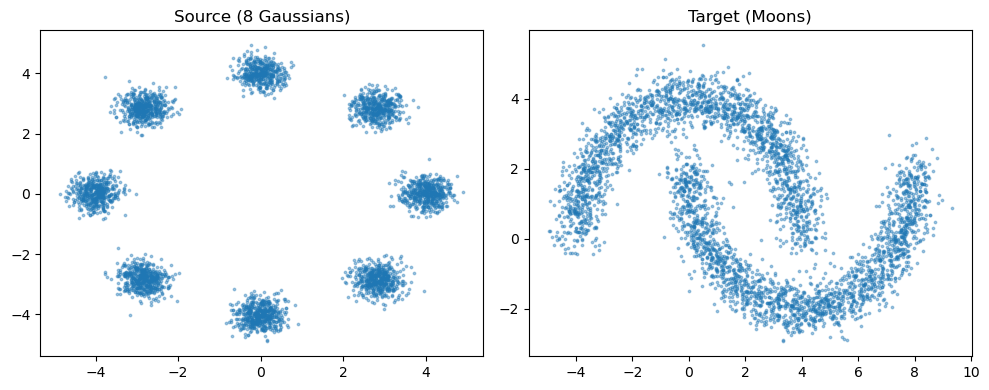

In [2]:
def sample_8gaussians(n, r=4.0, std=0.30, device="cpu"):
    angles = torch.arange(8, device=device) * (2 * math.pi / 8)
    centers = torch.stack([r * torch.cos(angles), r * torch.sin(angles)], dim=1)  # (8,2)
    idx = torch.randint(0, 8, (n,), device=device)
    x = centers[idx] + std * torch.randn(n, 2, device=device)
    return x

def sample_moons(n, noise=0.10, device="cpu"):
    # Simple moons without sklearn
    n1 = n // 2
    n2 = n - n1
    t1 = torch.rand(n1, device=device) * math.pi
    t2 = torch.rand(n2, device=device) * math.pi

    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1.0 - torch.cos(t2), 1.0 - torch.sin(t2) - 0.5], dim=1)
    x = torch.cat([x1, x2], dim=0)
    x = x + noise * torch.randn_like(x)
    x = 4.0 * x  # scale
    return x

# Quick visualization
n_vis = 4000
x0_true = sample_8gaussians(n_vis, device=device)
x1_true = sample_moons(n_vis, device=device)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(x0_true[:,0].cpu(), x0_true[:,1].cpu(), s=3, alpha=0.4)
plt.title("Source (8 Gaussians)")

plt.subplot(1,2,2)
plt.scatter(x1_true[:,0].cpu(), x1_true[:,1].cpu(), s=3, alpha=0.4)
plt.title("Target (Moons)")

plt.tight_layout()
plt.show()


In [3]:
def apply_missingness(x, p_drop_x=0.0, p_drop_y=0.0):
    B = x.shape[0]
    m = torch.ones(B, 2, device=x.device)

    if p_drop_x > 0:
        drop = (torch.rand(B, device=x.device) < p_drop_x)
        m[drop, 0] = 0.0
    if p_drop_y > 0:
        drop = (torch.rand(B, device=x.device) < p_drop_y)
        m[drop, 1] = 0.0

    noise = torch.randn_like(x)                 # N(0,1) for all entries
    x_pad = x * m + noise * (1.0 - m)          # keep observed, fill missing with noise
    return x_pad, m

def apply_missingness_no_all_missing(x, p_drop_x=0.0, p_drop_y=0.0):
    x_pad, m = apply_missingness(x, p_drop_x=p_drop_x, p_drop_y=p_drop_y)

    # if both missing, randomly keep one coord observed
    both = (m.sum(dim=1) == 0)
    if both.any():
        keep_x = (torch.rand(both.sum(), device=x.device) < 0.5)
        idx = both.nonzero(as_tuple=False).squeeze(1)
        m[idx[keep_x], 0] = 1.0
        m[idx[~keep_x], 1] = 1.0

        noise = torch.randn_like(x)
        x_pad = x * m + noise * (1.0 - m)

    return x_pad, m

In [4]:
p_drop_x0, p_drop_y0 = 0.3, 0.3
p_drop_x1, p_drop_y1 = 0.3, 0.3
x0_pad, m0 = apply_missingness_no_all_missing(x0_true, p_drop_x=p_drop_x0, p_drop_y=p_drop_y0)
x1_pad, m1 = apply_missingness_no_all_missing(x1_true, p_drop_x=p_drop_x1, p_drop_y=p_drop_y1)

mcap = m0 * m1

print("mean observed source:", m0.mean(0).cpu().numpy())
print("mean observed target:", m1.mean(0).cpu().numpy())
print("mean overlap:", mcap.mean(0).cpu().numpy())

mean observed source: [0.7455     0.73300004]
mean observed target: [0.74275005 0.7415    ]
mean overlap: [0.55550003 0.54550004]


In [5]:
# m0

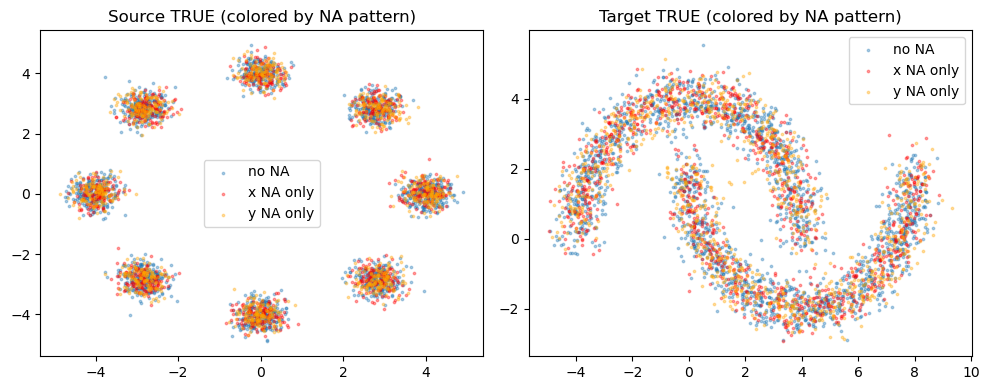

In [6]:
# pattern masks (works for both m0 and m1)
def split_missing_patterns(m):
    mx = (m[:,0] == 0)
    my = (m[:,1] == 0)
    none = (~mx) & (~my)
    x_only = mx & (~my)
    y_only = (~mx) & my
    both = mx & my
    return none.cpu().numpy(), x_only.cpu().numpy(), y_only.cpu().numpy(), both.cpu().numpy()

def scatter_by_missing(ax, x, m, title, plot_na_only = False):
    xnp = x.detach().cpu().numpy()
    none, x_only, y_only, both = split_missing_patterns(m)
    if not plot_na_only:
        ax.scatter(xnp[none,0],   xnp[none,1],   s=3, alpha=0.35, label="no NA")
    ax.scatter(xnp[x_only,0], xnp[x_only,1], s=3, alpha=0.35, c="r",      label="x NA only")
    ax.scatter(xnp[y_only,0], xnp[y_only,1], s=3, alpha=0.35, c="orange", label="y NA only")
    if both.sum() > 0:
        ax.scatter(xnp[both,0],   xnp[both,1],   s=3, alpha=0.35, c="purple", label="x&y NA")
    ax.set_title(title)
    ax.legend(loc="best")

fig, ax = plt.subplots(1,2, figsize=(10,4))
scatter_by_missing(ax[0], x0_true, m0, "Source TRUE (colored by NA pattern)")
scatter_by_missing(ax[1], x1_true, m1, "Target TRUE (colored by NA pattern)")
plt.tight_layout()
plt.show()

# 3. FM bridge and teacher

In [7]:
def sample_xt(x0_pad, x1_pad, t, sigma = 0.0):
    # x_t = (1-t) x0 + t x1 + sigma * eps
    eps = torch.randn_like(x0_pad)
    return (1.0 - t) * x0_pad + t * x1_pad + sigma * eps

def teacher_u(x0_pad, x1_pad):
    return x1_pad - x0_pad

class MLP(nn.Module):
    def __init__(self, in_dim=5, hid=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.SiLU(),
            nn.Linear(hid, hid),
            nn.SiLU(),
            nn.Linear(hid, out_dim),
        )

    def forward(self, xt, t, m0):
        inp = torch.cat([xt, t, m0], dim=1)
        return self.net(inp)


model = MLP(in_dim=5, hid=64, out_dim=2).to(device)
print("num params:", sum(p.numel() for p in model.parameters()))    

num params: 4674


# 4. Training

In [8]:
def train_masked_fm(
    model,
    steps=20000,
    batch_size=512,
    lr=2e-4,
    sigma=0.10,
    p_drop_x0 = 0.3,
    p_drop_y0 = 0.3,
    p_drop_x1 = 0.3,
    p_drop_y1 = 0.3,
    device="cpu",
):
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for k in range(steps):
        x0_true = sample_8gaussians(batch_size, device=device)
        x1_true = sample_moons(batch_size, device=device)

        # x0_pad, m0 = apply_missingness(x0_true, p_drop_x=p_drop_x0, p_drop_y=p_drop_y0)
        # x1_pad, m1 = apply_missingness(x1_true, p_drop_x=p_drop_x1, p_drop_y=p_drop_y1)

        x0_pad, m0 = apply_missingness_no_all_missing(x0_true, p_drop_x=p_drop_x0, p_drop_y=p_drop_y0)
        x1_pad, m1 = apply_missingness_no_all_missing(x1_true, p_drop_x=p_drop_x1, p_drop_y=p_drop_y1)
        
        # mcap = m0 * m1  # overlap mask
        mcap = m1  # overlap mask

        t = torch.rand(batch_size, 1, device=device)
        xt = sample_xt(x0_pad, x1_pad, t, sigma=sigma)
        u  = teacher_u(x0_pad, x1_pad)

        pred = model(xt, t, m0)  # condition on m0 only
        
        # denom = mcap.sum(dim=1).clamp_min(1.0)
        err = ((pred - u) ** 2) * mcap
        # loss = (err.sum(dim=1) / denom).mean()
        loss = (err.sum(dim=1)).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if (k + 1) % 1000 == 0:
            print(f"step {k+1:6d} | loss {loss.item():.4f}")

In [9]:
train_masked_fm(
    model,
    steps=100000,
    batch_size=512,
    lr=1e-3,
    sigma=0.01,
    p_drop_x0 = 0.3,
    p_drop_y0 = 0.3,
    p_drop_x1 = 0.3,
    p_drop_y1 = 0.3,
    device=device,
)


step   1000 | loss 14.2149
step   2000 | loss 12.8334
step   3000 | loss 14.0173
step   4000 | loss 14.9383
step   5000 | loss 12.2601
step   6000 | loss 13.4640
step   7000 | loss 13.0662
step   8000 | loss 13.2151
step   9000 | loss 13.2186
step  10000 | loss 12.6384
step  11000 | loss 12.2995
step  12000 | loss 12.7302
step  13000 | loss 12.1383
step  14000 | loss 13.8249
step  15000 | loss 12.3157
step  16000 | loss 13.6376
step  17000 | loss 11.8556
step  18000 | loss 12.3618
step  19000 | loss 12.4539
step  20000 | loss 12.9943
step  21000 | loss 13.0130
step  22000 | loss 12.9816
step  23000 | loss 12.0601
step  24000 | loss 13.2386
step  25000 | loss 12.4179
step  26000 | loss 13.2961
step  27000 | loss 11.8201
step  28000 | loss 12.1199
step  29000 | loss 12.1536
step  30000 | loss 11.5716
step  31000 | loss 12.1061
step  32000 | loss 12.7672
step  33000 | loss 13.1889
step  34000 | loss 11.5691
step  35000 | loss 13.7311
step  36000 | loss 12.7075
step  37000 | loss 12.2666
s

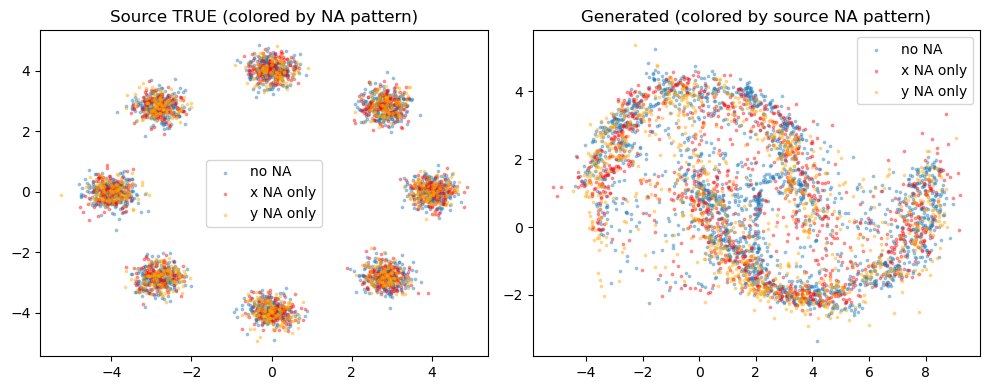

In [10]:
class VF_with_m0(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, t, z, args=None):
        # z: (B,4) = [x(2), m0(2)]
        x  = z[:, :2]
        m0 = z[:, 2:]

        # torchdyn may pass t as a scalar tensor, keep it float -> tensor
        tt = torch.full((z.shape[0], 1), float(t), device=z.device, dtype=z.dtype)

        dx = self.base(x, tt, m0)         # (B,2)
        dm = torch.zeros_like(m0)         # (B,2)
        return torch.cat([dx, dm], dim=1) # (B,4)


@torch.no_grad()
def sample_via_dopri5(model, x0_pad, m0, tau_init=0.0, n_t=101):
    # x0_pad already contains N(0,1) on missing coords.
    # tau_init lets you add extra noise if you really want, but default is 0.
    if tau_init != 0.0:
        x0 = x0_pad + (1.0 - m0) * (tau_init * torch.randn_like(x0_pad))
    else:
        x0 = x0_pad

    z0 = torch.cat([x0, m0], dim=1)

    node = NeuralODE(VF_with_m0(model), solver="dopri5", atol=1e-4, rtol=1e-4)
    t_span = torch.linspace(0, 1, n_t, device=x0.device, dtype=x0.dtype)
    traj = node.trajectory(z0, t_span=t_span)

    xT = traj[-1][:, :2]
    return xT, traj[:, :, :2]

# Generate
n_gen = 4000
x0_true = sample_8gaussians(n_gen, device=device)

# SAME as training
# x0_pad, m0 = apply_missingness(x0_true, p_drop_x=0.3, p_drop_y=0.3)
x0_pad, m0 = apply_missingness_no_all_missing(x0_true, p_drop_x=0.3, p_drop_y=0.3)


tau_lat = 0.0
x_gen, _ = sample_via_dopri5(model, x0_pad, m0, tau_init=tau_lat, n_t=2)

miss0 = (m0.sum(dim=1) < 2).detach().cpu().numpy()

x0_np = x0_true.detach().cpu().numpy()
xg_np = x_gen.detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
scatter_by_missing(ax[0], x0_true, m0, "Source TRUE (colored by NA pattern)")
scatter_by_missing(ax[1], x_gen,  m0, "Generated (colored by source NA pattern)")

plt.tight_layout()
plt.show()


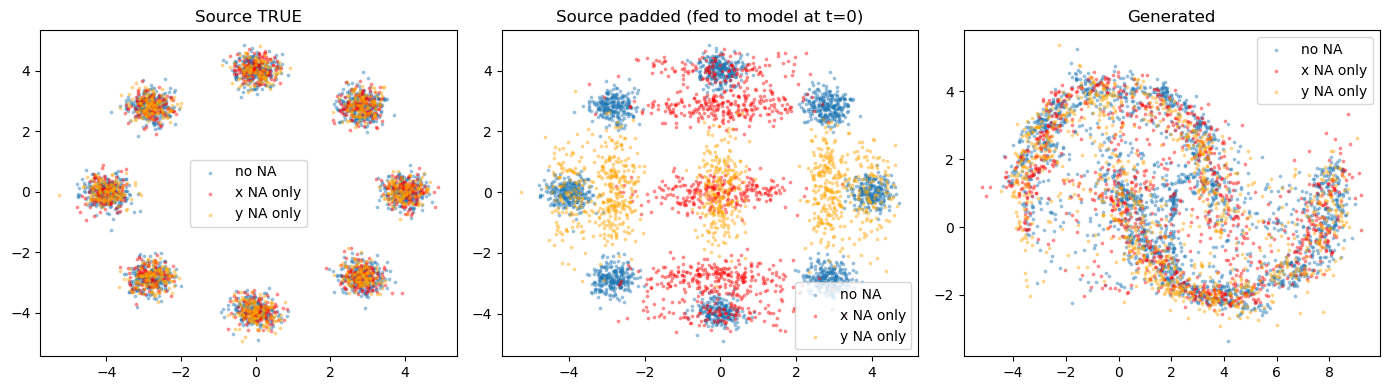

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
scatter_by_missing(ax[0], x0_true, m0, "Source TRUE")
scatter_by_missing(ax[1], x0_pad,  m0, "Source padded (fed to model at t=0)")
scatter_by_missing(ax[2], x_gen,   m0, "Generated")
plt.tight_layout()
plt.show()

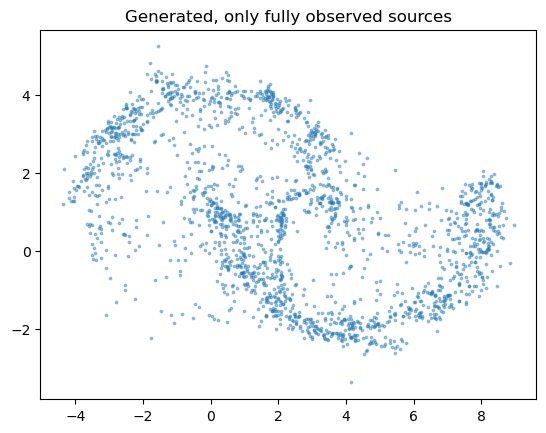

In [12]:
keep = (m0.sum(dim=1) == 2)
x_gen_keep, _ = sample_via_dopri5(model, x0_pad[keep], m0[keep], tau_init=0.0, n_t=101)
plt.scatter(x_gen_keep[:,0].cpu(), x_gen_keep[:,1].cpu(), s=3, alpha=0.4)
plt.title("Generated, only fully observed sources")
plt.show()

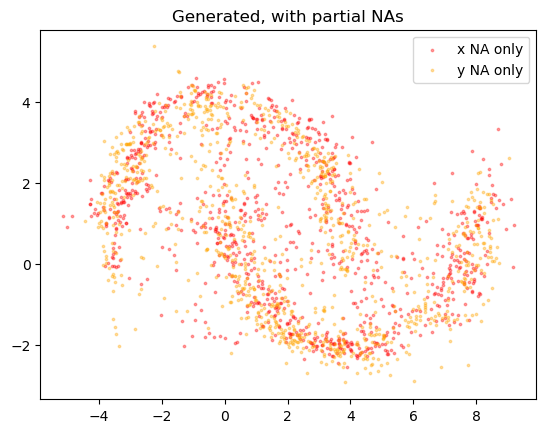

In [13]:
fig, ax = plt.subplots(1, 1,)
scatter_by_missing(ax, x_gen,   m0, "Generated, with partial NAs", plot_na_only=True)

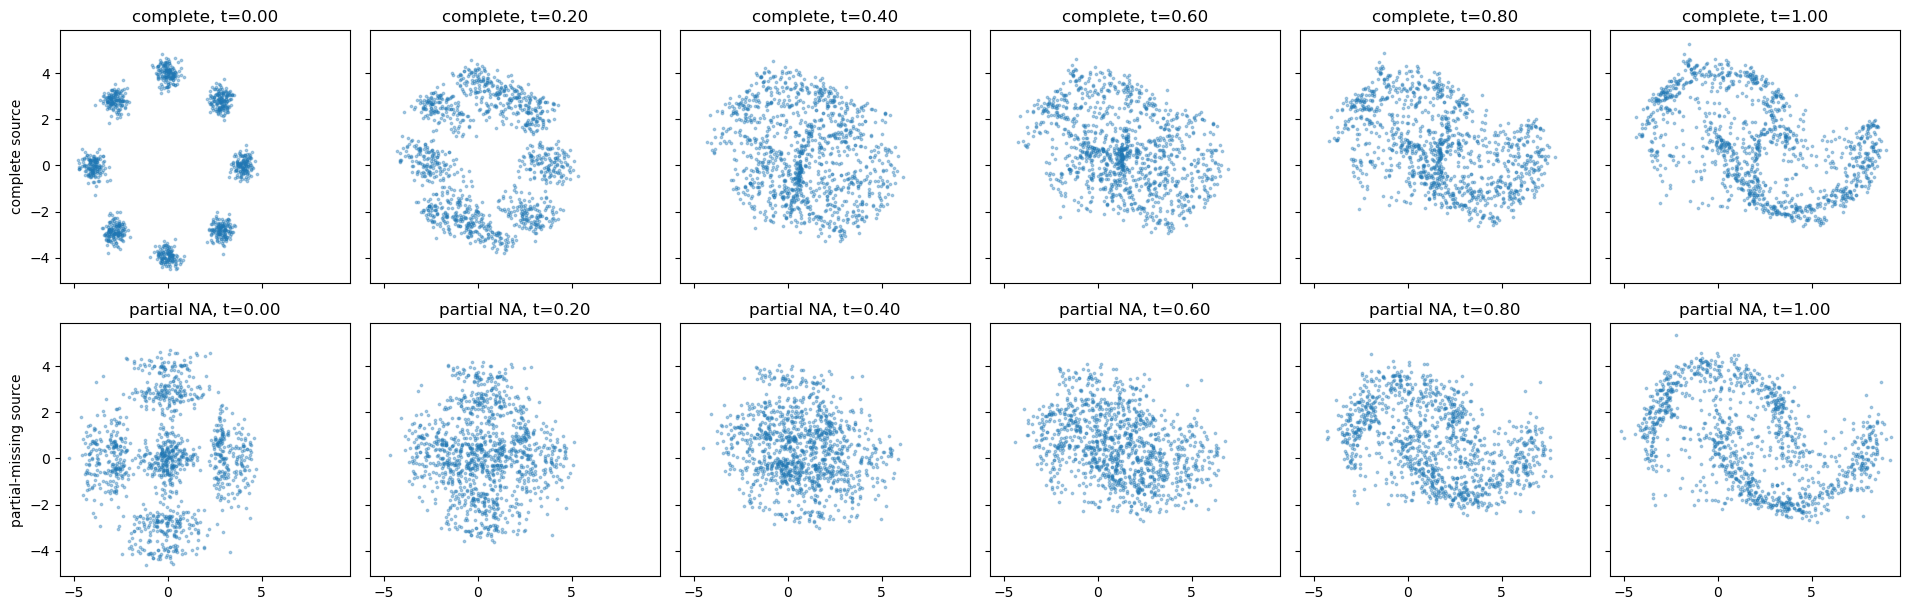

In [14]:
idx_full = (m0.sum(dim=1) == 2).nonzero(as_tuple=False).squeeze(1)   # complete (no NA)
idx_part = (m0.sum(dim=1) == 1).nonzero(as_tuple=False).squeeze(1)   # partial missing (exactly one NA)

# subsample for speed/clarity
max_per_group = 1200
if idx_full.numel() > max_per_group:
    idx_full = idx_full[torch.randperm(idx_full.numel(), device=device)[:max_per_group]]
if idx_part.numel() > max_per_group:
    idx_part = idx_part[torch.randperm(idx_part.numel(), device=device)[:max_per_group]]

x0_full, m0_full = x0_pad[idx_full], m0[idx_full]
x0_part, m0_part = x0_pad[idx_part], m0[idx_part]

# --- 2) integrate trajectories from padded source -> generated target (same solver as before) ---
# (tau_init=0 because x0_pad already has N(0,1) on missing coords)
xT_full, traj_full = sample_via_dopri5(model, x0_full, m0_full, tau_init=0.0, n_t=101)  # traj_full: (T,B,2)
xT_part, traj_part = sample_via_dopri5(model, x0_part, m0_part, tau_init=0.0, n_t=101)

# --- 3) choose snapshot times to visualize ---
T = traj_full.shape[0]
k = 6
snap_ids = np.linspace(0, T - 1, k, dtype=int)

# consistent axis limits across all panels
all_pts = torch.cat(
    [traj_full.reshape(-1, 2), traj_part.reshape(-1, 2)],
    dim=0
).detach().cpu().numpy()
xmin, ymin = all_pts.min(axis=0) - 0.5
xmax, ymax = all_pts.max(axis=0) + 0.5

# --- 4) plot: top row = complete source, bottom row = partial-missing source ---
fig, axes = plt.subplots(2, k, figsize=(3.2 * k, 6.2), sharex=True, sharey=True)

for j, tid in enumerate(snap_ids):
    # complete
    ax = axes[0, j]
    pts = traj_full[tid].detach().cpu().numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.35)
    ax.set_title(f"complete, t={tid/(T-1):.2f}")
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

    # partial missing
    ax = axes[1, j]
    pts = traj_part[tid].detach().cpu().numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.35)
    ax.set_title(f"partial NA, t={tid/(T-1):.2f}")
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

axes[0, 0].set_ylabel("complete source")
axes[1, 0].set_ylabel("partial-missing source")
plt.tight_layout()
plt.show()